# Building an Image Recognition System for Quality Control

## Automated Casting Defect Detection Using a Convolutional Neural Network

**Name:** P.Shadik Khan  
**Batch:** G40 AI ML

### Objective

To build a binary image classification system that automatically
classifies casting product images as defective or non-defective.

### Class Labels

- **0 = Non-defective (`ok_front`)**
- **1 = Defective (`def_front`)**

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
import os

# Dataset paths
base_dir = "../data"

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

print("Train directory:", train_dir)
print("Test directory:", test_dir)

print("\nTrain classes:")
print(os.listdir(train_dir))

print("\nTest classes:")
print(os.listdir(test_dir))

Train directory: ../data\train
Test directory: ../data\test

Train classes:
['def_front', 'ok_front']

Test classes:
['def_front', 'ok_front']


In [3]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Class names:", train_ds.class_names)

Found 1039 files belonging to 2 classes.
Found 261 files belonging to 2 classes.
Class names: ['def_front', 'ok_front']


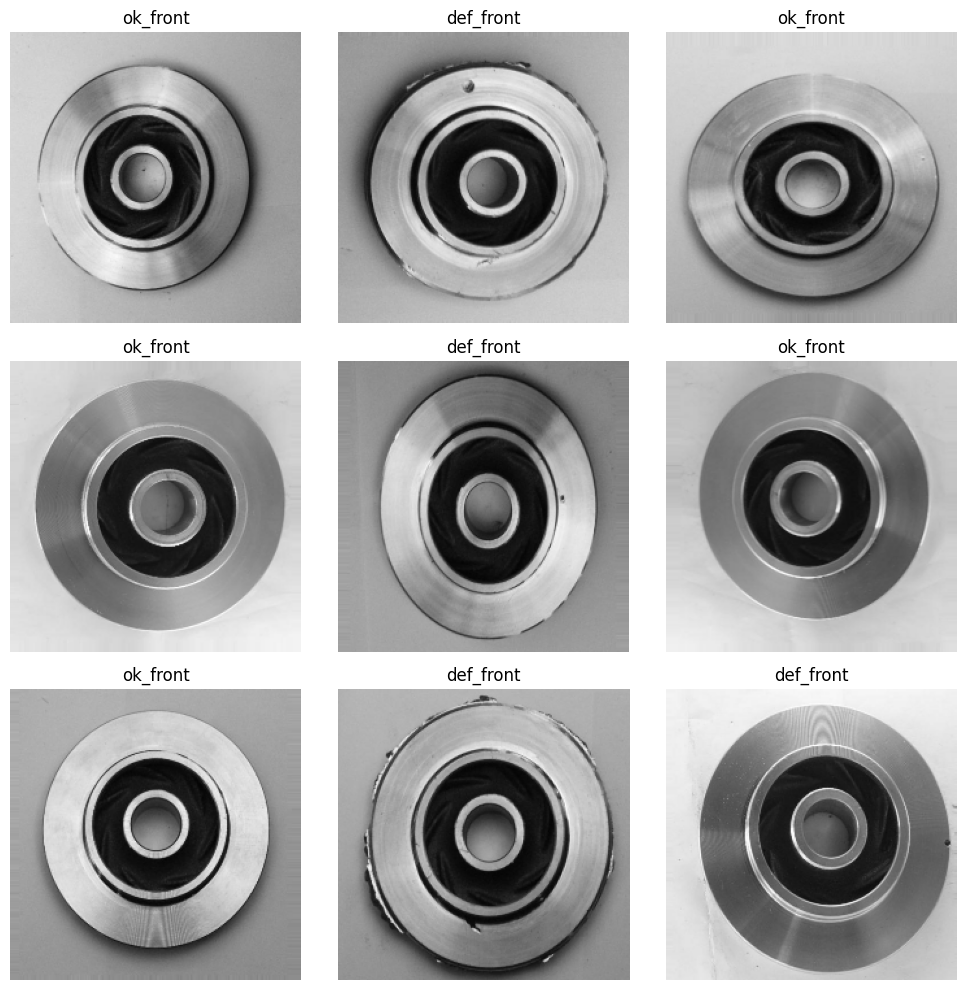

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        label = int(labels[i].numpy()[0])
        class_name = train_ds.class_names[label]
        
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Data augmentation for training images

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

# Normalize pixel values from 0-255 to 0-1
normalization_layer = layers.Rescaling(1./255)

print("Data augmentation and normalization layers created successfully.")

Data augmentation and normalization layers created successfully.


In [6]:
# Build the CNN model

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixel values
    normalization_layer,

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Classification layers
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile the CNN model

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [8]:
# Create training and validation datasets

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=SEED
)

print("Class names:", train_ds.class_names)

Found 1039 files belonging to 2 classes.
Using 832 files for training.
Found 1039 files belonging to 2 classes.
Using 207 files for validation.
Class names: ['def_front', 'ok_front']


In [9]:
# Callbacks to save the best model and stop early if needed

checkpoint_path = "../models/best_casting_defect_model.keras"

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Callbacks created successfully.")

Callbacks created successfully.


In [10]:
# Train the CNN model

EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/15


c:\Users\patan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.5721 - loss: 0.7749
Epoch 1: val_accuracy improved from None to 0.55556, saving model to ../models/best_casting_defect_model.keras

Epoch 1: finished saving model to ../models/best_casting_defect_model.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 448ms/step - accuracy: 0.5721 - loss: 0.7749 - val_accuracy: 0.5556 - val_loss: 0.6501
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.6707 - loss: 0.6136
Epoch 2: val_accuracy improved from 0.55556 to 0.64251, saving model to ../models/best_casting_defect_model.keras

Epoch 2: finished saving model to ../models/best_casting_defect_model.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 554ms/step - accuracy: 0.6707 - loss: 0.6136 - val_accuracy: 0.6425 - val_loss: 0.6141
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.6875 - loss: 0.5830
Epoch 3: val_accuracy improved from 0.64251 to 0.72464, saving model to ../models/best_casting_defect_model.keras

Epoch 3: finished savin

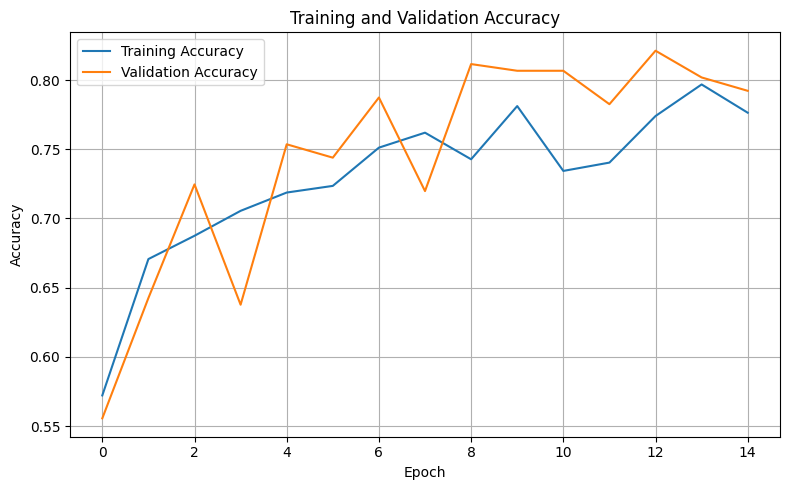

In [11]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("../reports/accuracy_graph.png", dpi=300)
plt.show()

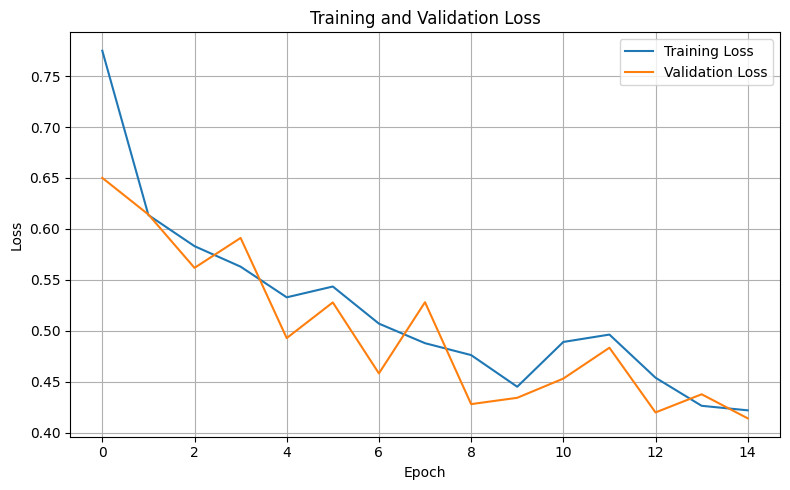

In [12]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("../reports/loss_graph.png", dpi=300)
plt.show()

In [13]:
import os

print("Accuracy graph exists:", os.path.exists("../reports/accuracy_graph.png"))
print("Loss graph exists:", os.path.exists("../reports/loss_graph.png"))
print("Best model exists:", os.path.exists("../models/best_casting_defect_model.keras"))

Accuracy graph exists: True
Loss graph exists: True
Best model exists: True


In [14]:
# Evaluate the best model on the test dataset

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.7854 - loss: 0.4052

Test Loss: 0.4052
Test Accuracy: 0.7854
Test Accuracy: 78.54%


In [15]:
# Generate predictions for the test dataset

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten().astype(int))
    y_pred.extend((predictions.flatten() >= 0.5).astype(int))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Total test images:", len(y_true))
print("Predictions generated:", len(y_pred))

Total test images: 261
Predictions generated: 261


Classification Report:

               precision    recall  f1-score   support

    Defective     0.8389    0.7962    0.8170       157
Non-defective     0.7143    0.7692    0.7407       104

     accuracy                         0.7854       261
    macro avg     0.7766    0.7827    0.7789       261
 weighted avg     0.7893    0.7854    0.7866       261



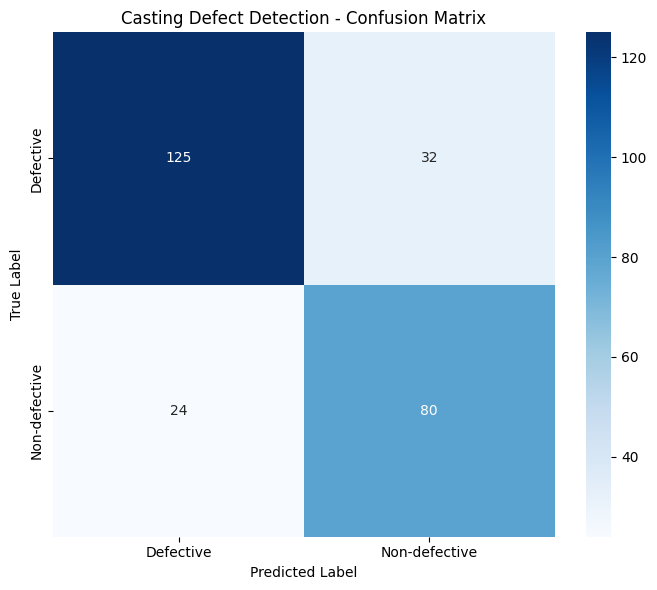

In [16]:
# Confusion Matrix and Classification Report

class_names = ["Defective", "Non-defective"]

print("Classification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Casting Defect Detection - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig("../reports/confusion_matrix.png", dpi=300)
plt.show()

Number of sample images: 5


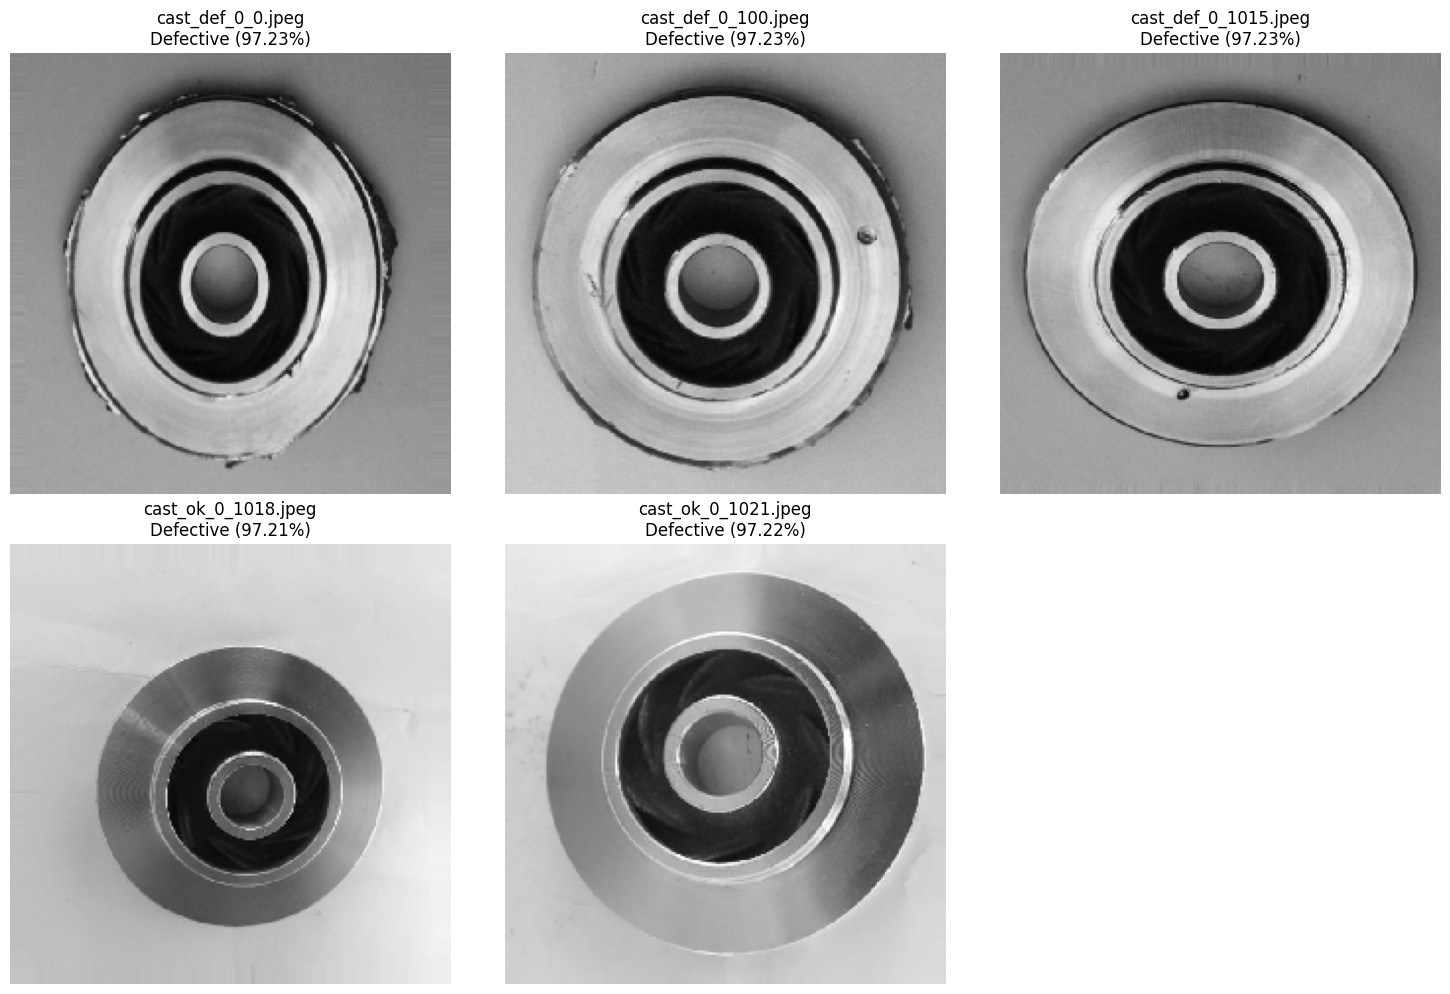

In [17]:
# Predict five unseen sample images

import glob
from tensorflow.keras.utils import load_img, img_to_array

sample_dir = "../sample_images"

sample_files = glob.glob(os.path.join(sample_dir, "*.jpeg"))
sample_files += glob.glob(os.path.join(sample_dir, "*.jpg"))
sample_files += glob.glob(os.path.join(sample_dir, "*.png"))

sample_files = sample_files[:5]

print("Number of sample images:", len(sample_files))

plt.figure(figsize=(15, 10))

for i, image_path in enumerate(sample_files):
    image = load_img(image_path, target_size=IMG_SIZE)
    image_array = img_to_array(image) / 255.0
    image_batch = np.expand_dims(image_array, axis=0)

    prediction = model.predict(image_batch, verbose=0)[0][0]

    # Model mapping:
    # 0 = Defective
    # 1 = Non-defective
    predicted_class = "Non-defective" if prediction >= 0.5 else "Defective"
    
    confidence = prediction if prediction >= 0.5 else 1 - prediction

    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(
        f"{os.path.basename(image_path)}\n"
        f"{predicted_class} ({confidence * 100:.2f}%)"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

Number of sample images: 5


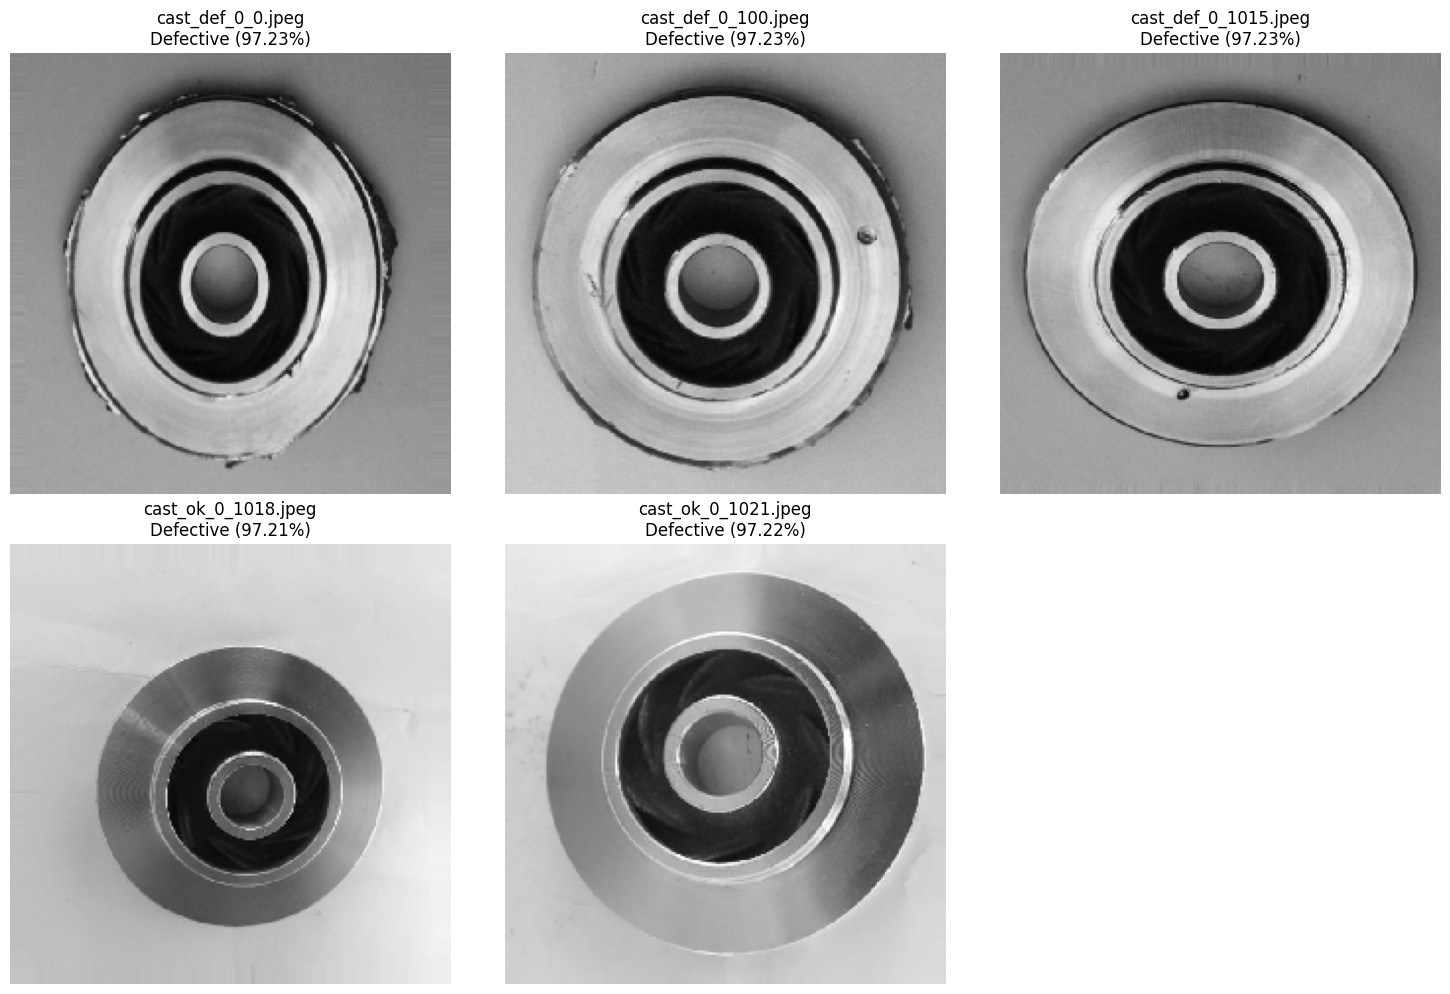

In [18]:
# Predict five unseen sample images

import glob
from tensorflow.keras.utils import load_img, img_to_array

sample_dir = "../sample_images"

sample_files = glob.glob(os.path.join(sample_dir, "*.jpeg"))
sample_files += glob.glob(os.path.join(sample_dir, "*.jpg"))
sample_files += glob.glob(os.path.join(sample_dir, "*.png"))

sample_files = sample_files[:5]

print("Number of sample images:", len(sample_files))

plt.figure(figsize=(15, 10))

for i, image_path in enumerate(sample_files):
    image = load_img(image_path, target_size=IMG_SIZE)
    image_array = img_to_array(image) / 255.0
    image_batch = np.expand_dims(image_array, axis=0)

    prediction = model.predict(image_batch, verbose=0)[0][0]

    # TensorFlow mapping:
    # 0 = def_front (Defective)
    # 1 = ok_front (Non-defective)
    predicted_class = "Non-defective" if prediction >= 0.5 else "Defective"

    confidence = prediction if prediction >= 0.5 else 1 - prediction

    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(
        f"{os.path.basename(image_path)}\n"
        f"{predicted_class} ({confidence * 100:.2f}%)"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

Number of sample images: 5


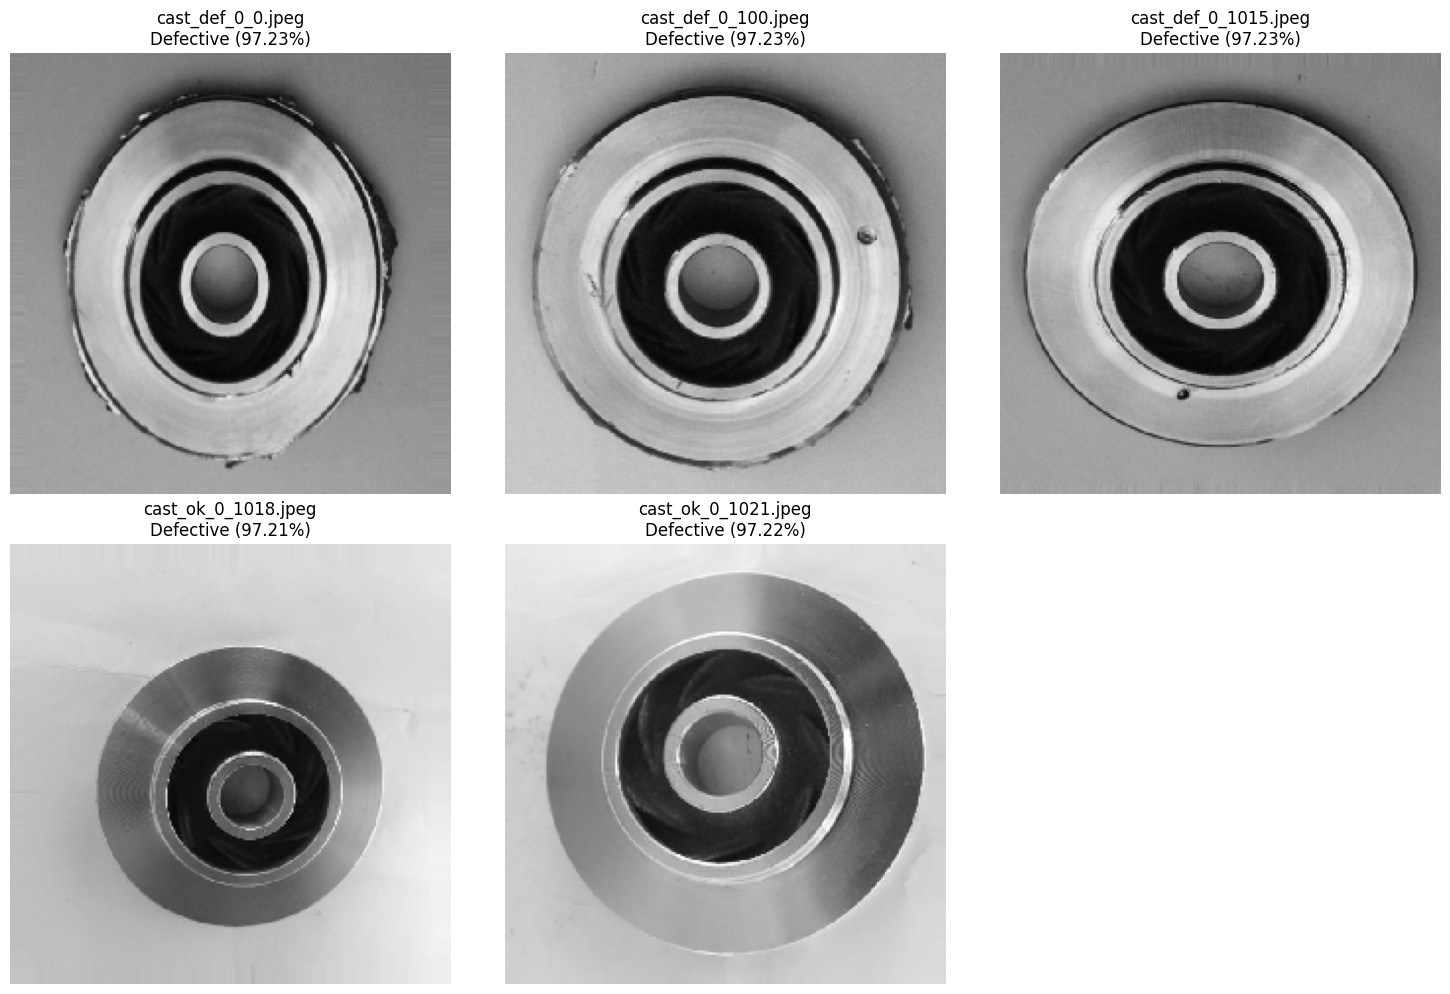

In [19]:
# Predict five unseen sample images

import glob
from tensorflow.keras.utils import load_img, img_to_array

sample_dir = "../sample_images"

sample_files = glob.glob(os.path.join(sample_dir, "*.jpeg"))
sample_files += glob.glob(os.path.join(sample_dir, "*.jpg"))
sample_files += glob.glob(os.path.join(sample_dir, "*.png"))

sample_files = sample_files[:5]

print("Number of sample images:", len(sample_files))

plt.figure(figsize=(15, 10))

for i, image_path in enumerate(sample_files):
    image = load_img(image_path, target_size=IMG_SIZE)
    image_array = img_to_array(image) / 255.0
    image_batch = np.expand_dims(image_array, axis=0)

    prediction = model.predict(image_batch, verbose=0)[0][0]

    # TensorFlow mapping:
    # 0 = def_front = Defective
    # 1 = ok_front = Non-defective
    predicted_class = "Non-defective" if prediction >= 0.5 else "Defective"

    confidence = prediction if prediction >= 0.5 else 1 - prediction

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(
        f"{os.path.basename(image_path)}\n"
        f"{predicted_class} ({confidence * 100:.2f}%)"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()